<a href="https://colab.research.google.com/github/Crosshairs532/404_not_found/blob/main/career_switch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. Data description
  This Dataset contains the information of the 5000 people. The information consists of where they live, how developed the cities are. Along with that it contains the information of the people's education desciplines,their working places , work experince etc.

  ### 1.a Columns Description
   - `enrollee_id`: This is the unique identifier of a person.
   - `city`: This represents the city code, which is a unique identifier of a city.
   - `city_development_index`: This is value that indicated how developed a city is.
   
   - `gender`: Gender of a person.
   - `relevent_experience`: Relevant experience of a person ( Yes/No).
   - `enrolled_university`: Enrollment type in a university (part time / full time). If any
   - `education_level`: Eduction Level type ('Graduate', 'Masters', 'High School', 'Phd', 'Primary School). if any
   - `major_discipline`: Major of a candidate had on their education level.
   - `experience`: Years of a experience of a candidate.(if any)
   - `company_size`: How big the company is based on the members.
   - `company_type`: Type of the company.
   - `last_new_job`: How many years have passed till the current Job.
   - `training_hours`: Training hours completed.
   - `will_change_career`: Whether the candidate will switch the career or not. This comes in (`Yes`/`1`) or (`No`/`0`)


  ### 1.b Columns Type
    - `Numerical`: city_development_index, training_hours, will_change_career (binary).
    - `Categorical/Ordinal`: gender, relevent_experience, enrolled_university, education_level, major_discipline, experience, company_size, company_type, last_new_job.
    - `Mixed/ID`: enrollee_id, city.
   

| Column                   | Issue                        | Quality (completeness > validity, accuracy, consistency)                                               |
|--------------------------|------------------------------|-------------------------------------------------------|
| `City`                   | `No issue`                   | `Okay`                                                |
| `city_development_index` | `No issue`                   | `Okay`                                                |
| `gender`                 | `null values`                | `completeness`                                        |
| `relevent_experience`    | `Long Sentence`("No relevent experience")            | `Accuracy`                                            |
| `enrolled_university`    | `null values`,               | `completeness`, `inconsistent`                        |
| `education_level`        | `null values`                | `completeness`                                        |
| `major_discipline`       | `null values`                | `completeness`                                        |
| `experience`             | `null values`, `Corrupted data`(>20, <4) | `completeness`, `inconsistent`, `invalid`, `inaccurate` |
| `company_size`           | `null values`, `Corrupted data`   | `completeness`, `inconsistent`, `invalid`, `inaccurate` |
| `company_type`           | `null values`                | `completeness`                         |
| `last_new_job`           | `null values`, `Corrupt data`| `completeness`, `inconsistent`, `invalid`             |
| `training_hours`         | `Okay`                       | `Okay`                                                |
| `will_change_career`     | `Okay`                       | `Okay`                                                |


## Feature Engineering
  ### 1.a Feature Transformation
          - Handle missing values - DONE
          - Feature Scaling- DONE
          - Encoding(Categorical + Numerical) - DONE
          - Outlier detection - DONE
  


In [184]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [185]:
career_df  = pd.read_csv("E:\ONI\ML-DL-GENAI\projects\career-switch-ML\Career_Switch_Prediction_Dataset.csv")
df = career_df.copy()
df.isnull().sum()

enrollee_id                  0
city                         0
city_development_index       0
gender                    1113
relevent_experience          0
enrolled_university        107
education_level            118
major_discipline           724
experience                  11
company_size              1571
company_type              1621
last_new_job               104
training_hours               0
will_change_career           0
dtype: int64

# EDA

   - categorical: `gender`, `relevent_experience`, `enrolled_university`, `major_descipline`, `education_level`, `company_type`.

<Axes: title={'center': 'Number of Class'}>

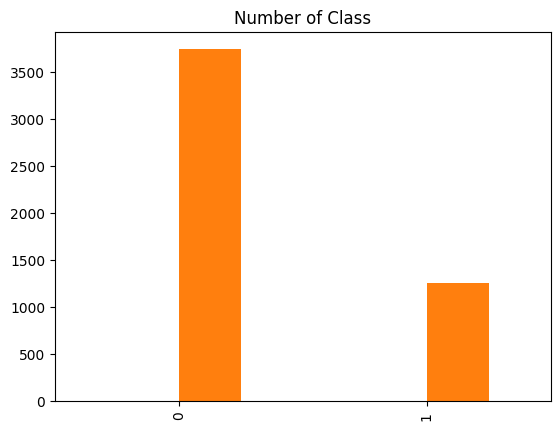

In [186]:
# number of classes

# # sns.barplot(data=df, x="will_change_career", y=df.groupby("will_change_career")["will_change_career"].sum())
pd.DataFrame(df.groupby("will_change_career")["will_change_career"].value_counts()).reset_index().plot(kind="bar", legend=False, title="Number of Class")

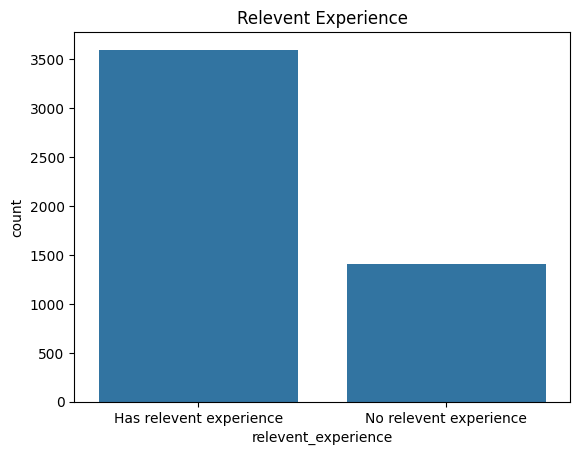

In [187]:
# relevent_experience
plt.title("Relevent Experience")
sns.countplot(data=df, x=df["relevent_experience"])
plt.show()

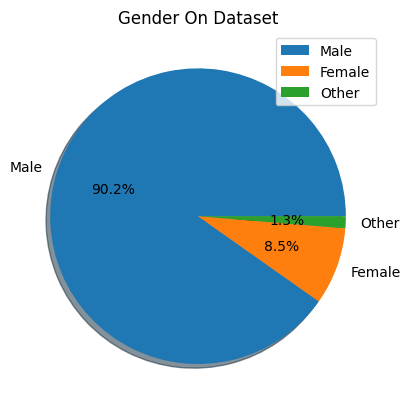

In [188]:
# gender

plt.title("Gender On Dataset")
plt.pie(df['gender'].value_counts(), labels=df['gender'].value_counts().reset_index()["gender"], autopct='%1.1f%%', shadow=True)
plt.legend(loc="best")
plt.show()


<Axes: title={'center': 'University Enrollment with Gender'}, xlabel='enrolled_university', ylabel='count'>

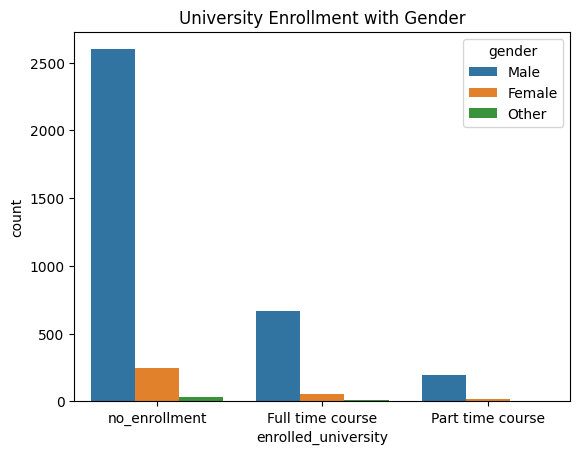

In [189]:
# enrolled_university

df["enrolled_university"]
plt.title("University Enrollment with Gender")
sns.countplot(data=df, x=df["enrolled_university"], hue="gender", fill=True)


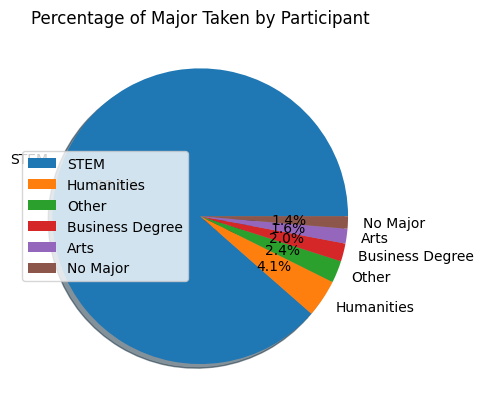

In [190]:
# major descipline
plt.title("Percentage of Major Taken by Participant")
plt.pie(df['major_discipline'].value_counts(), labels=df['major_discipline'].value_counts().reset_index()["major_discipline"], autopct='%1.1f%%', shadow=True)
plt.legend(loc="best")
plt.show()

<Axes: title={'center': 'Education Level'}, xlabel='education_level', ylabel='percent'>

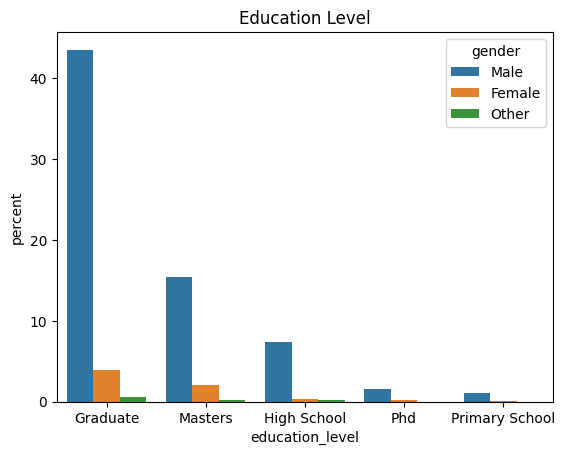

In [191]:
# Which type of education level is highest
plt.title("Education Level")
sns.countplot(data=df, x="education_level", stat="percent", hue="gender", fill=True)


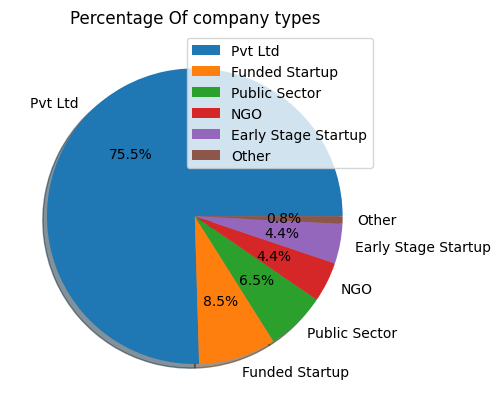

In [192]:
# compnay type
plt.title("Percentage Of company types")
plt.pie(data=df, x=df["company_type"].value_counts(), labels=df["company_type"].value_counts().reset_index()["company_type"], autopct='%1.1f%%', shadow=True)

plt.legend(loc="best")
plt.show()




<Axes: title={'center': 'Relation of Major discipline with University Enrollment'}, xlabel='major_discipline', ylabel='count'>

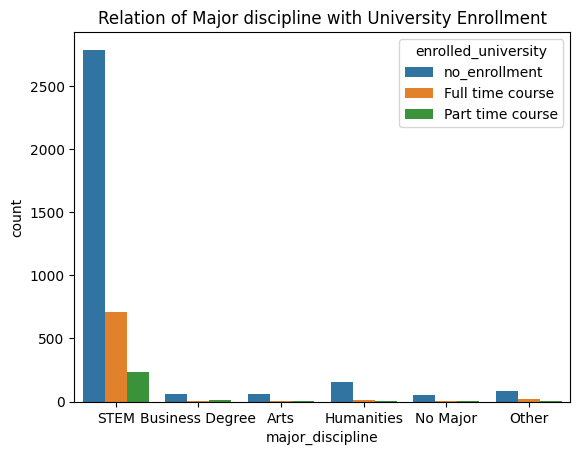

In [193]:
# major discpline , enrolled_univerisy
plt.title("Relation of Major discipline with University Enrollment")
sns.countplot(data=df, x=df["major_discipline"], fill=True, hue="enrolled_university")

   - Numerical: `city_development_index`, `experience`, `company size`, `last_new_job`, `training_hours`, `will_change_career`.


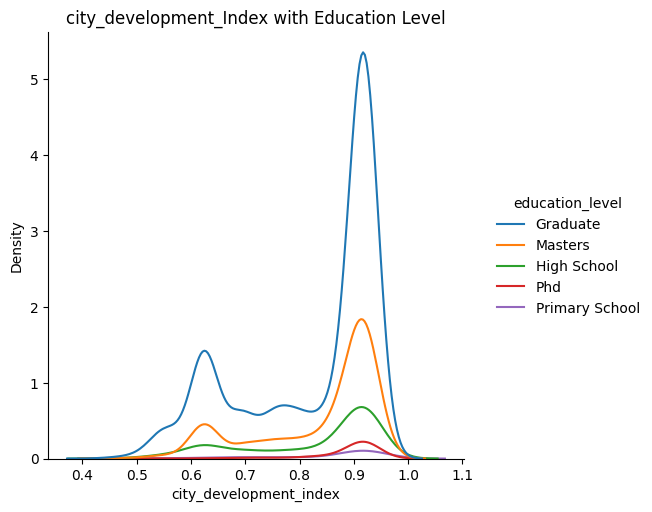

In [194]:
# plt.title()
sns.displot(data=df,x="city_development_index", kind="kde", hue="education_level").set(
    title="city_development_Index with Education Level")
plt.show()
# sns.displot(data=df,x="city_development_index", kind="kde", hue="enrolled_university")
# sns.displot(data=df,x="city_development_index", kind="kde", hue="major_discipline")

<Axes: xlabel='city_development_index', ylabel='Density'>

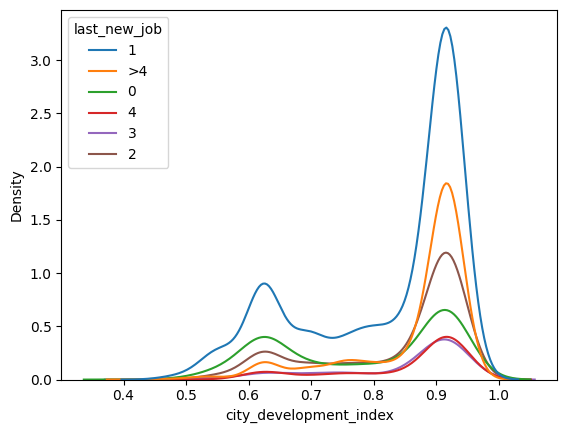

In [195]:
# city_development_index - last_New_job


# sns.scatterplot(data=df, y="last_new_job", x="experience")
sns.kdeplot(data=df, x="city_development_index", hue="last_new_job",)

<Axes: xlabel='will_change_career', ylabel='training_hours'>

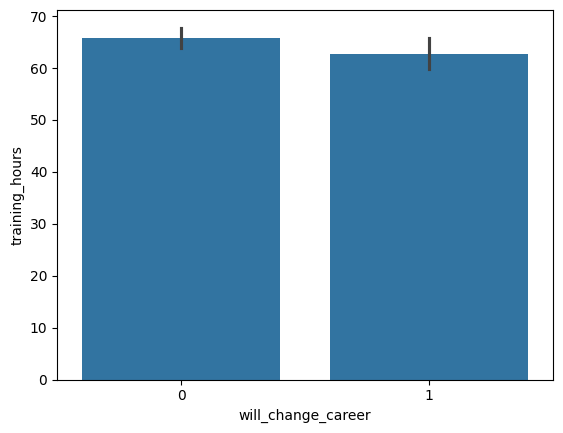

In [196]:
# city_development_index - training_hours
# city_development_index - experience
sns.barplot(data=df, x="will_change_career", y= "training_hours")


# Feature Engineering

#### (a) Handling Mixed Data / Inconsistent Data

In [197]:
# city
df["city"] = df["city"].str.split("_", expand=True)[1]
df["city"] = df["city"].astype("int")
df["city"].head(2)

0    103
1     40
Name: city, dtype: int64

In [198]:
#  relevant_experience
df["relevent_experience"] = np.where(df["relevent_experience"] == 'Has relevent experience', 1, 0)

In [199]:
df["enrolled_university"].unique()

array(['no_enrollment', 'Full time course', nan, 'Part time course'],
      dtype=object)

In [200]:
df[["enrolled_university"]].isnull().mean() * 100

enrolled_university    2.14
dtype: float64

In [201]:
# enrolled_university

from sklearn.impute import SimpleImputer
impute_mode  = SimpleImputer(strategy='most_frequent')
df["enrolled_university"] = impute_mode.fit_transform(df[["enrolled_university"]]).ravel()

In [202]:
df["experience"].isnull().sum()
df["experience"].head(10
                      )
df["experience"].unique()

array(['>20', '15', '5', '<1', '11', '13', '7', '17', '2', '16', '1', '4',
       '10', '14', '18', '19', '12', '3', '6', '9', '8', '20', nan],
      dtype=object)

In [203]:
# experience

df["experience"] = df["experience"].replace({"<1": "0", ">20": "21"})
df["experience"] = df["experience"].astype(float) 


In [204]:
df["experience"].isnull().sum()
df["experience"].head(10
                      )


0    21.0
1    15.0
2     5.0
3     0.0
4    21.0
5    11.0
6     5.0
7    13.0
8     7.0
9    17.0
Name: experience, dtype: float64

In [205]:
df["company_size"].unique()

array([nan, '50-99', '<10', '10000+', '5000-9999', '1000-4999', 'Oct-49',
       '100-500', '500-999'], dtype=object)

In [206]:
# Company_size
size_mapping = {
    "10000+": "10000-20000", 
    "Oct-49": "10-49", 
    "<10": "1-9"
}
df["company_size"] = df["company_size"].replace(size_mapping)

In [207]:
df["company_size"].isnull().sum()

np.int64(1571)

In [208]:
df[["company_size_min", "company_size_max"]] = df["company_size"].str.split("-", expand=True)

In [209]:
df[["company_size_min", "company_size_max"]].isnull().sum()

company_size_min    1571
company_size_max    1571
dtype: int64

In [210]:
df["company_size_min"] = pd.to_numeric(df["company_size_min"], errors='coerce')
df["company_size_max"] = pd.to_numeric(df["company_size_max"], errors='coerce')

In [211]:
df[["company_size_min", "company_size_max"]].isnull().sum()

company_size_min    1571
company_size_max    1571
dtype: int64

In [212]:
df.drop("company_size", axis=1, inplace=True)

In [213]:
# last new job
df['last_new_job'] = df['last_new_job'].replace({'>4': '5', 'never': '0'})
df['last_new_job'] = df['last_new_job'].astype(float)

#### b) Handle Missing Categorical  Value

In [214]:
(df.isnull().sum() / len(df))*100

enrollee_id                0.00
city                       0.00
city_development_index     0.00
gender                    22.26
relevent_experience        0.00
enrolled_university        0.00
education_level            2.36
major_discipline          14.48
experience                 0.22
company_type              32.42
last_new_job               2.08
training_hours             0.00
will_change_career         0.00
company_size_min          31.42
company_size_max          31.42
dtype: float64

In [215]:
df.dtypes

enrollee_id                 int64
city                        int64
city_development_index    float64
gender                     object
relevent_experience         int64
enrolled_university        object
education_level            object
major_discipline           object
experience                float64
company_type               object
last_new_job              float64
training_hours              int64
will_change_career          int64
company_size_min          float64
company_size_max          float64
dtype: object

In [216]:
df["relevent_experience"].head()

0    1
1    0
2    0
3    0
4    1
Name: relevent_experience, dtype: int64

In [217]:

cat_high_nulls = ["gender", "company_type", "major_discipline"]
cat_low_nulls  = ["education_level", "enrolled_university"]
num_cols       =["experience", "last_new_job", "company_size_min", "company_size_max"]

In [218]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer


smp = SimpleImputer(strategy="most_frequent")
smp_missing = SimpleImputer(strategy="constant", fill_value="Missing")
smp_median  = SimpleImputer(strategy="median")

ct = ColumnTransformer(
    transformers=[
        ("cat_high", smp_missing, cat_high_nulls),
        ("cat_low", smp, cat_low_nulls),
        ("num", smp_median, num_cols)
    ], 
    remainder="passthrough",
    verbose_feature_names_out=False 
)

transformed  = ct.fit_transform(df)

saved_column_names = ct.get_feature_names_out()

print(saved_column_names)


['gender' 'company_type' 'major_discipline' 'education_level'
 'enrolled_university' 'experience' 'last_new_job' 'company_size_min'
 'company_size_max' 'enrollee_id' 'city' 'city_development_index'
 'relevent_experience' 'training_hours' 'will_change_career']


In [219]:
df_clean = pd.DataFrame(transformed, columns=saved_column_names)


for col in num_cols:
    if col in df_clean.columns:

        df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')

In [220]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   gender                  5000 non-null   object 
 1   company_type            5000 non-null   object 
 2   major_discipline        5000 non-null   object 
 3   education_level         5000 non-null   object 
 4   enrolled_university     5000 non-null   object 
 5   experience              5000 non-null   float64
 6   last_new_job            5000 non-null   float64
 7   company_size_min        5000 non-null   float64
 8   company_size_max        5000 non-null   float64
 9   enrollee_id             5000 non-null   object 
 10  city                    5000 non-null   object 
 11  city_development_index  5000 non-null   object 
 12  relevent_experience     5000 non-null   object 
 13  training_hours          5000 non-null   object 
 14  will_change_career      5000 non-null   

In [221]:
df_clean.head()

,gender,company_type,major_discipline,education_level,enrolled_university,experience,last_new_job,company_size_min,company_size_max,enrollee_id,city,city_development_index,relevent_experience,training_hours,will_change_career
0,Male,Missing,STEM,Graduate,no_enrollment,21.0,1.0,100.0,500.0,8949.0,103.0,0.92,1.0,36.0,1.0
1,Male,Pvt Ltd,STEM,Graduate,no_enrollment,15.0,5.0,50.0,99.0,29725.0,40.0,0.776,0.0,47.0,0.0
2,Missing,Missing,STEM,Graduate,Full time course,5.0,0.0,100.0,500.0,11561.0,21.0,0.624,0.0,83.0,0.0
3,Missing,Pvt Ltd,Business Degree,Graduate,no_enrollment,0.0,0.0,100.0,500.0,33241.0,115.0,0.789,0.0,52.0,1.0
4,Male,Funded Startup,STEM,Masters,no_enrollment,21.0,4.0,50.0,99.0,666.0,162.0,0.767,1.0,8.0,0.0


In [222]:
df_clean.drop(columns='enrollee_id', inplace=True)

In [223]:
df_clean[['relevent_experience', 'will_change_career']] = df_clean[['relevent_experience', 'will_change_career']].astype('int')
df_clean[['training_hours', 'city_development_index', 'city']] =  df_clean[['training_hours', 'city_development_index', 'city']].astype('float')


In [224]:
df_clean.info()
df_clean.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   gender                  5000 non-null   object 
 1   company_type            5000 non-null   object 
 2   major_discipline        5000 non-null   object 
 3   education_level         5000 non-null   object 
 4   enrolled_university     5000 non-null   object 
 5   experience              5000 non-null   float64
 6   last_new_job            5000 non-null   float64
 7   company_size_min        5000 non-null   float64
 8   company_size_max        5000 non-null   float64
 9   city                    5000 non-null   float64
 10  city_development_index  5000 non-null   float64
 11  relevent_experience     5000 non-null   int64  
 12  training_hours          5000 non-null   float64
 13  will_change_career      5000 non-null   int64  
dtypes: float64(7), int64(2), object(5)
memor

gender                    0
company_type              0
major_discipline          0
education_level           0
enrolled_university       0
experience                0
last_new_job              0
company_size_min          0
company_size_max          0
city                      0
city_development_index    0
relevent_experience       0
training_hours            0
will_change_career        0
dtype: int64

# Till Now Done
- Handled Mixed Data
- handled Missing Values
- Handle Data Type

# Outier Detection

Numerical
- ['city_development_index',
 'relevent_experience',
 'experience',
 'last_new_job',
 'training_hours',
 'will_change_career',
 'company_size_min',
 'company_size_max', 'city']

In [225]:
#training_hours

#using IQR
percentile25 = df['training_hours'].quantile(0.25)
percentile75 = df['training_hours'].quantile(0.75)
iqr = percentile75 - percentile25
upper_limit = percentile75 + 1.5 * iqr
lower_limit = percentile25 - 1.5 * iqr

df_clean[(df_clean["training_hours"] > upper_limit) | (df_clean["training_hours"]< lower_limit)]

# capping
df_clean["training_hours"] = np.where(df_clean["training_hours"] > upper_limit, upper_limit, np.where(df_clean["training_hours"]<lower_limit, lower_limit,df_clean["training_hours"]))


# Train Test Split

In [226]:
X = df_clean.loc[: , df_clean.drop('will_change_career', axis = 1).columns]
y = df_clean.loc[:, "will_change_career"]
X

,gender,company_type,major_discipline,education_level,enrolled_university,experience,last_new_job,company_size_min,company_size_max,city,city_development_index,relevent_experience,training_hours
0,Male,Missing,STEM,Graduate,no_enrollment,21.0,1.0,100.0,500.0,103.0,0.920,1,36.0
1,Male,Pvt Ltd,STEM,Graduate,no_enrollment,15.0,5.0,50.0,99.0,40.0,0.776,0,47.0
2,Missing,Missing,STEM,Graduate,Full time course,5.0,0.0,100.0,500.0,21.0,0.624,0,83.0
3,Missing,Pvt Ltd,Business Degree,Graduate,no_enrollment,0.0,0.0,100.0,500.0,115.0,0.789,0,52.0
4,Male,Funded Startup,STEM,Masters,no_enrollment,21.0,4.0,50.0,99.0,162.0,0.767,1,8.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,Female,Missing,STEM,Graduate,no_enrollment,3.0,1.0,100.0,500.0,21.0,0.624,1,114.0
4996,Male,Pvt Ltd,STEM,Graduate,no_enrollment,3.0,1.0,100.0,500.0,21.0,0.624,0,64.0
4997,Male,Pvt Ltd,Missing,High School,no_enrollment,21.0,5.0,5000.0,9999.0,16.0,0.910,0,89.0
4998,Female,Pvt Ltd,STEM,Graduate,no_enrollment,10.0,5.0,10000.0,20000.0,103.0,0.920,1,20.0


In [227]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42,stratify=y)


In [228]:
X_train.shape, X_test.shape

((3500, 13), (1500, 13))

# Function Transform

In [229]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import PowerTransformer
import pandas as pd


cols_to_transform = ['city_development_index', 'experience', 'last_new_job', 'training_hours', 'company_size_max']


ct_transform = ColumnTransformer([
    ("power", PowerTransformer(method='yeo-johnson'), cols_to_transform)
], remainder="passthrough")


X_train_transformed = ct_transform.fit_transform(X_train)
X_test_transformed = ct_transform.transform(X_test)


X_train_after_transform = pd.DataFrame(X_train_transformed, columns=ct_transform.get_feature_names_out(), index=X_train.index)
X_test_after_transform = pd.DataFrame(X_test_transformed, columns=ct_transform.get_feature_names_out(), index=X_test.index)


X_train_after_transform.columns = [c.split("__")[-1] for c in X_train_after_transform.columns]
X_test_after_transform.columns = [c.split("__")[-1] for c in X_test_after_transform.columns]


for col in cols_to_transform:
    print(f"{col} -> Before: {X_train[col].skew():.2f}, After: {X_train_after_transform[col].skew():.2f}")

city_development_index -> Before: -1.04, After: -0.58
experience -> Before: 0.42, After: -0.10
last_new_job -> Before: 0.83, After: 0.01
training_hours -> Before: 1.06, After: -0.05
company_size_max -> Before: 2.25, After: 0.00


# Feature Encoding

Target
 - will_change_career - Not needed


Categorical
- [gender',
 'education_level',
 'enrolled_university',
 'company_type',
 'major_discipline',
]

Numerical
- ['city_development_index',
 'relevent_experience',
 'experience',
 'last_new_job',
 'training_hours',
 'will_change_career',
 'company_size_min',
 'company_size_max']

## Encoding

* Gender - One Hot Encoding
*  education_level - Ordinal Encoding
*  enrolled_university - One Hot Encoding
*  company_type - One Hot Encoding
*  major_discipline - One Hot Encoding

In [230]:
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer

lb = LabelEncoder()
oe = OrdinalEncoder(categories=[["Primary School", 'High School', 'Graduate', "Masters", "Phd"]], handle_unknown='use_encoded_value', unknown_value=-1)
ohe = OneHotEncoder(sparse_output=False, drop="first", handle_unknown='ignore')

ct = ColumnTransformer(
    [
    ("one_hot_encoding", ohe, ["gender", "enrolled_university", "company_type", "major_discipline"]),
    ("education_level_ordinal_encoding",oe, ["education_level"]),
    ],
    remainder="passthrough"
    )

x_train_encoded = ct.fit_transform(X_train_after_transform)
x_test_encoded = ct.transform(X_test_after_transform)


final_feature_names = ct.get_feature_names_out()


X_train_final_df = pd.DataFrame(x_train_encoded, columns=final_feature_names)
X_test_final_df = pd.DataFrame(x_test_encoded, columns=final_feature_names)

X_train_final_df.columns = [c.split("__")[-1] for c in X_train_final_df.columns]
X_test_final_df.columns = [c.split("__")[-1] for c in X_test_final_df.columns]

In [231]:
X_train_after_transform.columns

Index(['city_development_index', 'experience', 'last_new_job',
       'training_hours', 'company_size_max', 'gender', 'company_type',
       'major_discipline', 'education_level', 'enrolled_university',
       'company_size_min', 'city', 'relevent_experience'],
      dtype='object')

## Feature Scaling

In [232]:
from sklearn.preprocessing import MinMaxScaler
mm = MinMaxScaler()


x_train_scaled = pd.DataFrame(
    mm.fit_transform(X_train_final_df), 
    columns=X_train_final_df.columns, 
    index=X_train_final_df.index
)

x_test_scaled = pd.DataFrame(
    mm.transform(X_test_final_df), 
    columns=X_test_final_df.columns, 
    index=X_test_final_df.index
)


x_train_scaled.head()


,gender_Male,gender_Missing,gender_Other,enrolled_university_Part time course,enrolled_university_no_enrollment,company_type_Funded Startup,company_type_Missing,company_type_NGO,company_type_Other,company_type_Public Sector,...,major_discipline_STEM,education_level,city_development_index,experience,last_new_job,training_hours,company_size_max,company_size_min,city,relevent_experience
0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.50,0.688015,0.918700,1.000000,0.640965,0.549386,0.009901,0.758427,0.0
1,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,1.0,1.00,0.813084,0.299653,0.000000,0.778147,0.549386,0.009901,0.573034,1.0
2,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,...,1.0,0.75,0.813084,0.478071,0.401443,0.814813,0.837614,0.099910,0.573034,0.0
3,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.50,0.068030,0.527060,0.401443,0.823481,1.000000,1.000000,0.112360,1.0
4,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.25,0.756380,0.365920,0.401443,0.320795,0.549386,0.009901,0.084270,0.0


# Till Now
- Handle Missing Data
- handle Mixed Data
- Handle Data type
- EDA
- Outlier Detection
- Function Transfromation(power)
- Encoding
- scaling



In [233]:
from sklearn.ensemble import RandomForestClassifier
import pandas as pd

model = RandomForestClassifier()
model.fit(x_train_scaled, y_train)

importances = model.feature_importances_

feature_importance_df = pd.DataFrame({
    'Feature': X_train_final_df.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

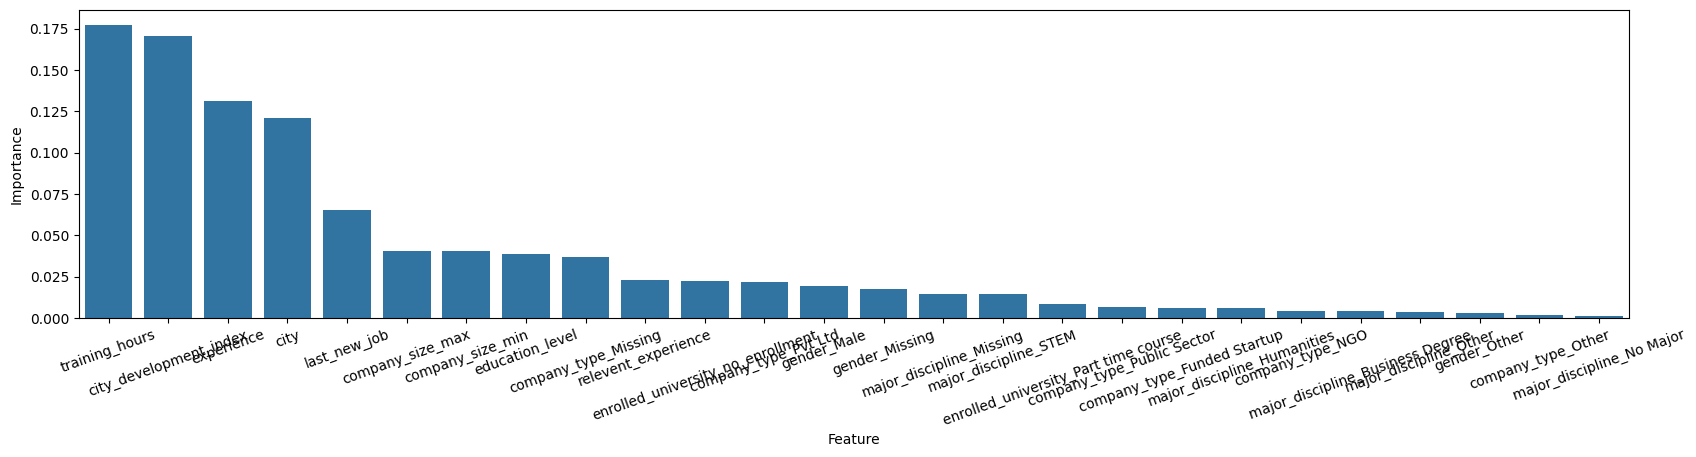

In [234]:
plt.figure(figsize=(20, 4))
sns.barplot(x=feature_importance_df["Feature"], y=feature_importance_df["Importance"])
plt.xticks(rotation=20)
plt.show()

processing: Logistic regression...
processing: GaussianNB...
processing: Decision Tree...
processing: Knn...

--- Final Model Comparison Table ---


,Model,Train_Acc,Test_Acc,CV_Mean,Precision,Recall,F1_Score,AUC_ROC
0,Logistic regression,0.714571,0.689333,0.710571,0.429952,0.704485,0.534000,0.746237
1,GaussianNB,0.704571,0.699333,0.694857,0.429412,0.577836,0.492688,0.694307
2,Decision Tree,0.801429,0.757333,0.784000,0.519894,0.517150,0.518519,0.746678
3,Knn,0.854857,0.730667,0.737429,0.462006,0.401055,0.429379,0.669229


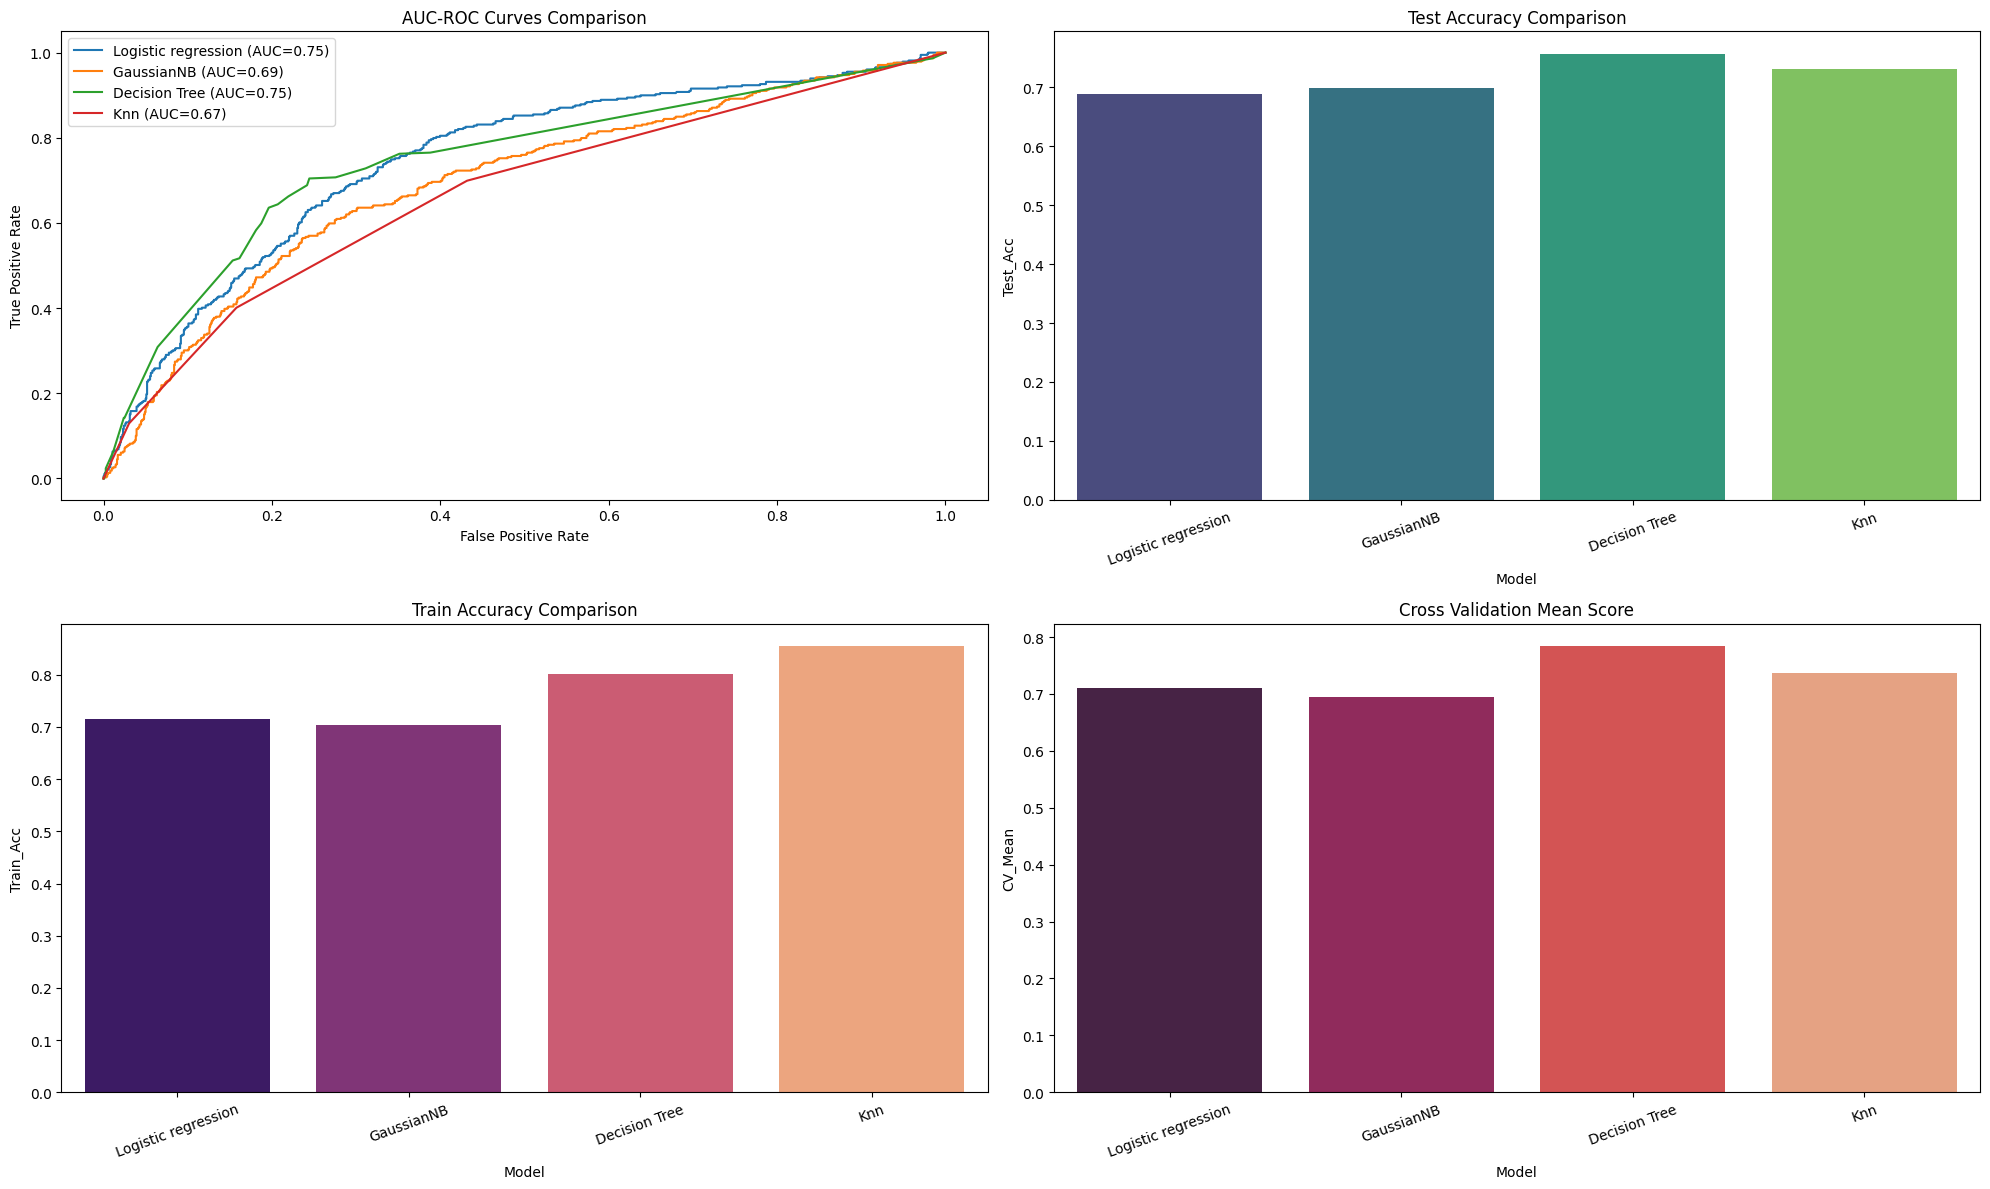

In [235]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, roc_auc_score, roc_curve, auc, confusion_matrix)


y_train = y_train.astype(int).values.ravel()
y_test = y_test.astype(int).values.ravel()

model_configs = {
    "Logistic regression": {
        "model": LogisticRegression(max_iter=2000, solver='liblinear'),
        "params": {"class_weight": [None, "balanced"], "C": [0.1, 1.0, 10.0]}
    },
    "GaussianNB": {
        "model": GaussianNB(),
        "params": {}
    },
    "Decision Tree": {
        "model": DecisionTreeClassifier(),
        "params": {'max_depth': [3, 5, 10, None], 'criterion': ['gini', 'entropy']}
    },
    "Knn": {
        "model": KNeighborsClassifier(),
        "params": {'n_neighbors': [3, 5, 7], 'weights': ['uniform', 'distance']}
    }
}


final_metrics = []
plt.figure(figsize=(20, 12))


for i, (name, config) in enumerate(model_configs.items()):
    print(f"processing: {name}...")
    

    grid = GridSearchCV(config["model"], config["params"], cv=5, scoring='f1', n_jobs=1)
    grid.fit(x_train_scaled, y_train)
    
    best_m = grid.best_estimator_
    

    y_pred = best_m.predict(x_test_scaled)
    y_train_pred = best_m.predict(x_train_scaled)
    

    y_prob = best_m.predict_proba(x_test_scaled)[:, 1] if hasattr(best_m, "predict_proba") else None
    

    acc_train = accuracy_score(y_train, y_train_pred)
    acc_test = accuracy_score(y_test, y_pred)
    cv_score = cross_val_score(best_m, x_train_scaled, y_train, cv=10).mean()
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    auc_val = roc_auc_score(y_test, y_prob) if y_prob is not None else 0
    

    final_metrics.append({
        "Model": name,
        "Train_Acc": acc_train,
        "Test_Acc": acc_test,
        "CV_Mean": cv_score,
        "Precision": prec,
        "Recall": rec,
        "F1_Score": f1,
        "AUC_ROC": auc_val
    })
    
    plt.subplot(2, 2, 1)
    if y_prob is not None:
        fpr, tpr, _ = roc_curve(y_test, y_prob)
        plt.plot(fpr, tpr, label=f"{name} (AUC={auc_val:.2f})")
    plt.title("AUC-ROC Curves Comparison")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend()


metrics_df = pd.DataFrame(final_metrics)
print("\n--- Final Model Comparison Table ---")
display(metrics_df)


names = metrics_df["Model"]

plt.subplot(2, 2, 2)
sns.barplot(x=names, y=metrics_df["Test_Acc"], hue=names, palette="viridis", legend=False)
plt.title("Test Accuracy Comparison")
plt.xticks(rotation=20)

plt.subplot(2, 2, 3)
sns.barplot(x=names, y=metrics_df["Train_Acc"], hue=names, palette="magma", legend=False)
plt.title("Train Accuracy Comparison")
plt.xticks(rotation=20)

plt.subplot(2, 2, 4)
sns.barplot(x=names, y=metrics_df["CV_Mean"], hue=names, palette="rocket", legend=False)
plt.title("Cross Validation Mean Score")
plt.xticks(rotation=20)

plt.tight_layout()
plt.show()